# Escuchar música generada
Reproduce los archivos MIDI generados por el modelo.

In [27]:
import os
import pygame
import time
import pretty_midi
import matplotlib.pyplot as plt


In [28]:
# Cambia a True si corres en Google Colab
COLAB = False

if COLAB:
    GENERATED_DIR = '/content/drive/MyDrive/MASTER NLP_2/Microproyecto_1/generated'
else:
    GENERATED_DIR = './generated'


number = 1
songs = ['scratch_song_1_media.mid', 'scratch_song_2_media_mas_1sigma.mid', 'scratch_song_3_media_menos_1sigma.mid']
song = songs[number]

print(f'Carpeta de MIDIs: {GENERATED_DIR}')
print('Archivos disponibles:')
for f in sorted(os.listdir(GENERATED_DIR)):
    if f.endswith('.mid'):
        print(f'  {f}')


Carpeta de MIDIs: ./generated
Archivos disponibles:
  beethoven_1_4_topk_5.mid
  beethoven_bs100_hand1.mid
  beethoven_combined.mid
  beethoven_gen_1.mid
  beethoven_gen_1_5.mid
  beethoven_gen_1_good_1_2.mid
  beethoven_gen_2.mid
  beethoven_gen_2_good_1_2.mid
  beethoven_gen_3.mid
  beethoven_gen_3_good_1_2.mid
  beethoven_hand2.mid
  beethoven_topk_bs100_combined.mid
  beethoven_topk_bs100_hand1.mid
  beethoven_topk_hand1.mid
  beethoven_topk_hand2.mid
  dual_temperatura_semilla_song0.mid
  enhanced_gen_seq0.mid
  enhanced_semilla_gen_seq0.mid
  scratch_song_1_media.mid
  scratch_song_2_media_mas_1sigma.mid
  scratch_song_3_media_menos_1sigma.mid
  semilla_genera.mid
  semilla_generado_1.mid
  semilla_generado_2.mid
  semilla_generado_3.mid
  semilla_generado_dual_seq0.mid
  semilla_generado_final0.mid
  semilla_generado_final1.mid
  semilla_generado_mejorado.mid
  semilla_generado_mejorado_final.mid
  semilla_temp_seq0.mid


In [29]:
def play_midi(filepath, seconds=15):
    """Reproduce un archivo MIDI durante 'seconds' segundos."""
    pygame.mixer.init()
    pygame.mixer.music.load(filepath)
    pygame.mixer.music.play()
    print(f'Reproduciendo: {os.path.basename(filepath)} ({seconds}s)...')
    time.sleep(seconds)
    pygame.mixer.music.stop()
    print('Listo.')


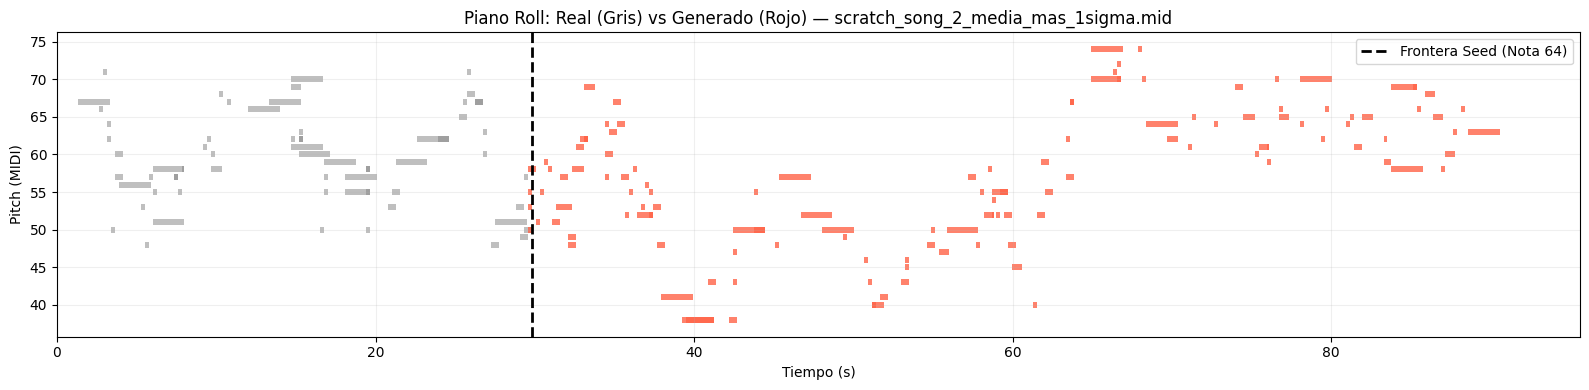

Notas Reales (Seed): 64
Notas Generadas:     136
El "Beethoven IA" empezó a componer en el segundo: 29.84s


In [30]:
# --- Piano roll con división Real vs Generado ---
MIDI_NUM = 0
midi_path = os.path.join(GENERATED_DIR, f'/Users/sebastian/Library/Mobile Documents/com~apple~CloudDocs/Maestria Andes/Tercer semestre/Natural Language Processing 2/MAIA_NLP_2/Microproyectos/Microproyecto_1/Sebastian/generated/{song}')

pm = pretty_midi.PrettyMIDI(midi_path)
notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)

# Definimos el límite basado en tu BLOCK_SIZE
SEED_LIMIT = 64  # Notas 0 a 63 son reales

fig, ax = plt.subplots(figsize=(16, 4))

for i, note in enumerate(notes):
    # Diferenciamos color: Gris para lo real, Tomate para lo generado
    color = 'gray' if i < SEED_LIMIT else 'tomato'
    alpha = 0.5 if i < SEED_LIMIT else 0.8
    
    ax.barh(note.pitch, note.end - note.start, left=note.start,
            height=0.8, color=color, alpha=alpha)
    
    # Marcamos el tiempo exacto donde termina el seed
    if i == SEED_LIMIT - 1:
        time_boundary = note.end

# Línea vertical divisoria
ax.axvline(time_boundary, color='black', linestyle='--', linewidth=2, 
           label=f'Frontera Seed (Nota {SEED_LIMIT})')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Pitch (MIDI)')
ax.set_title(f'Piano Roll: Real (Gris) vs Generado (Rojo) — {song}')
ax.set_xlim(0, pm.get_end_time() + 5) # Ajuste dinámico del tiempo
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Notas Reales (Seed): {SEED_LIMIT}')
print(f'Notas Generadas:     {len(notes) - SEED_LIMIT}')
print(f'El "Beethoven IA" empezó a componer en el segundo: {time_boundary:.2f}s')

In [31]:
# Escuchar una canción generada — cambia el número (1, 2 o 3)
play_midi(os.path.join(GENERATED_DIR, song), seconds=75)


Reproduciendo: scratch_song_2_media_mas_1sigma.mid (75s)...
Listo.


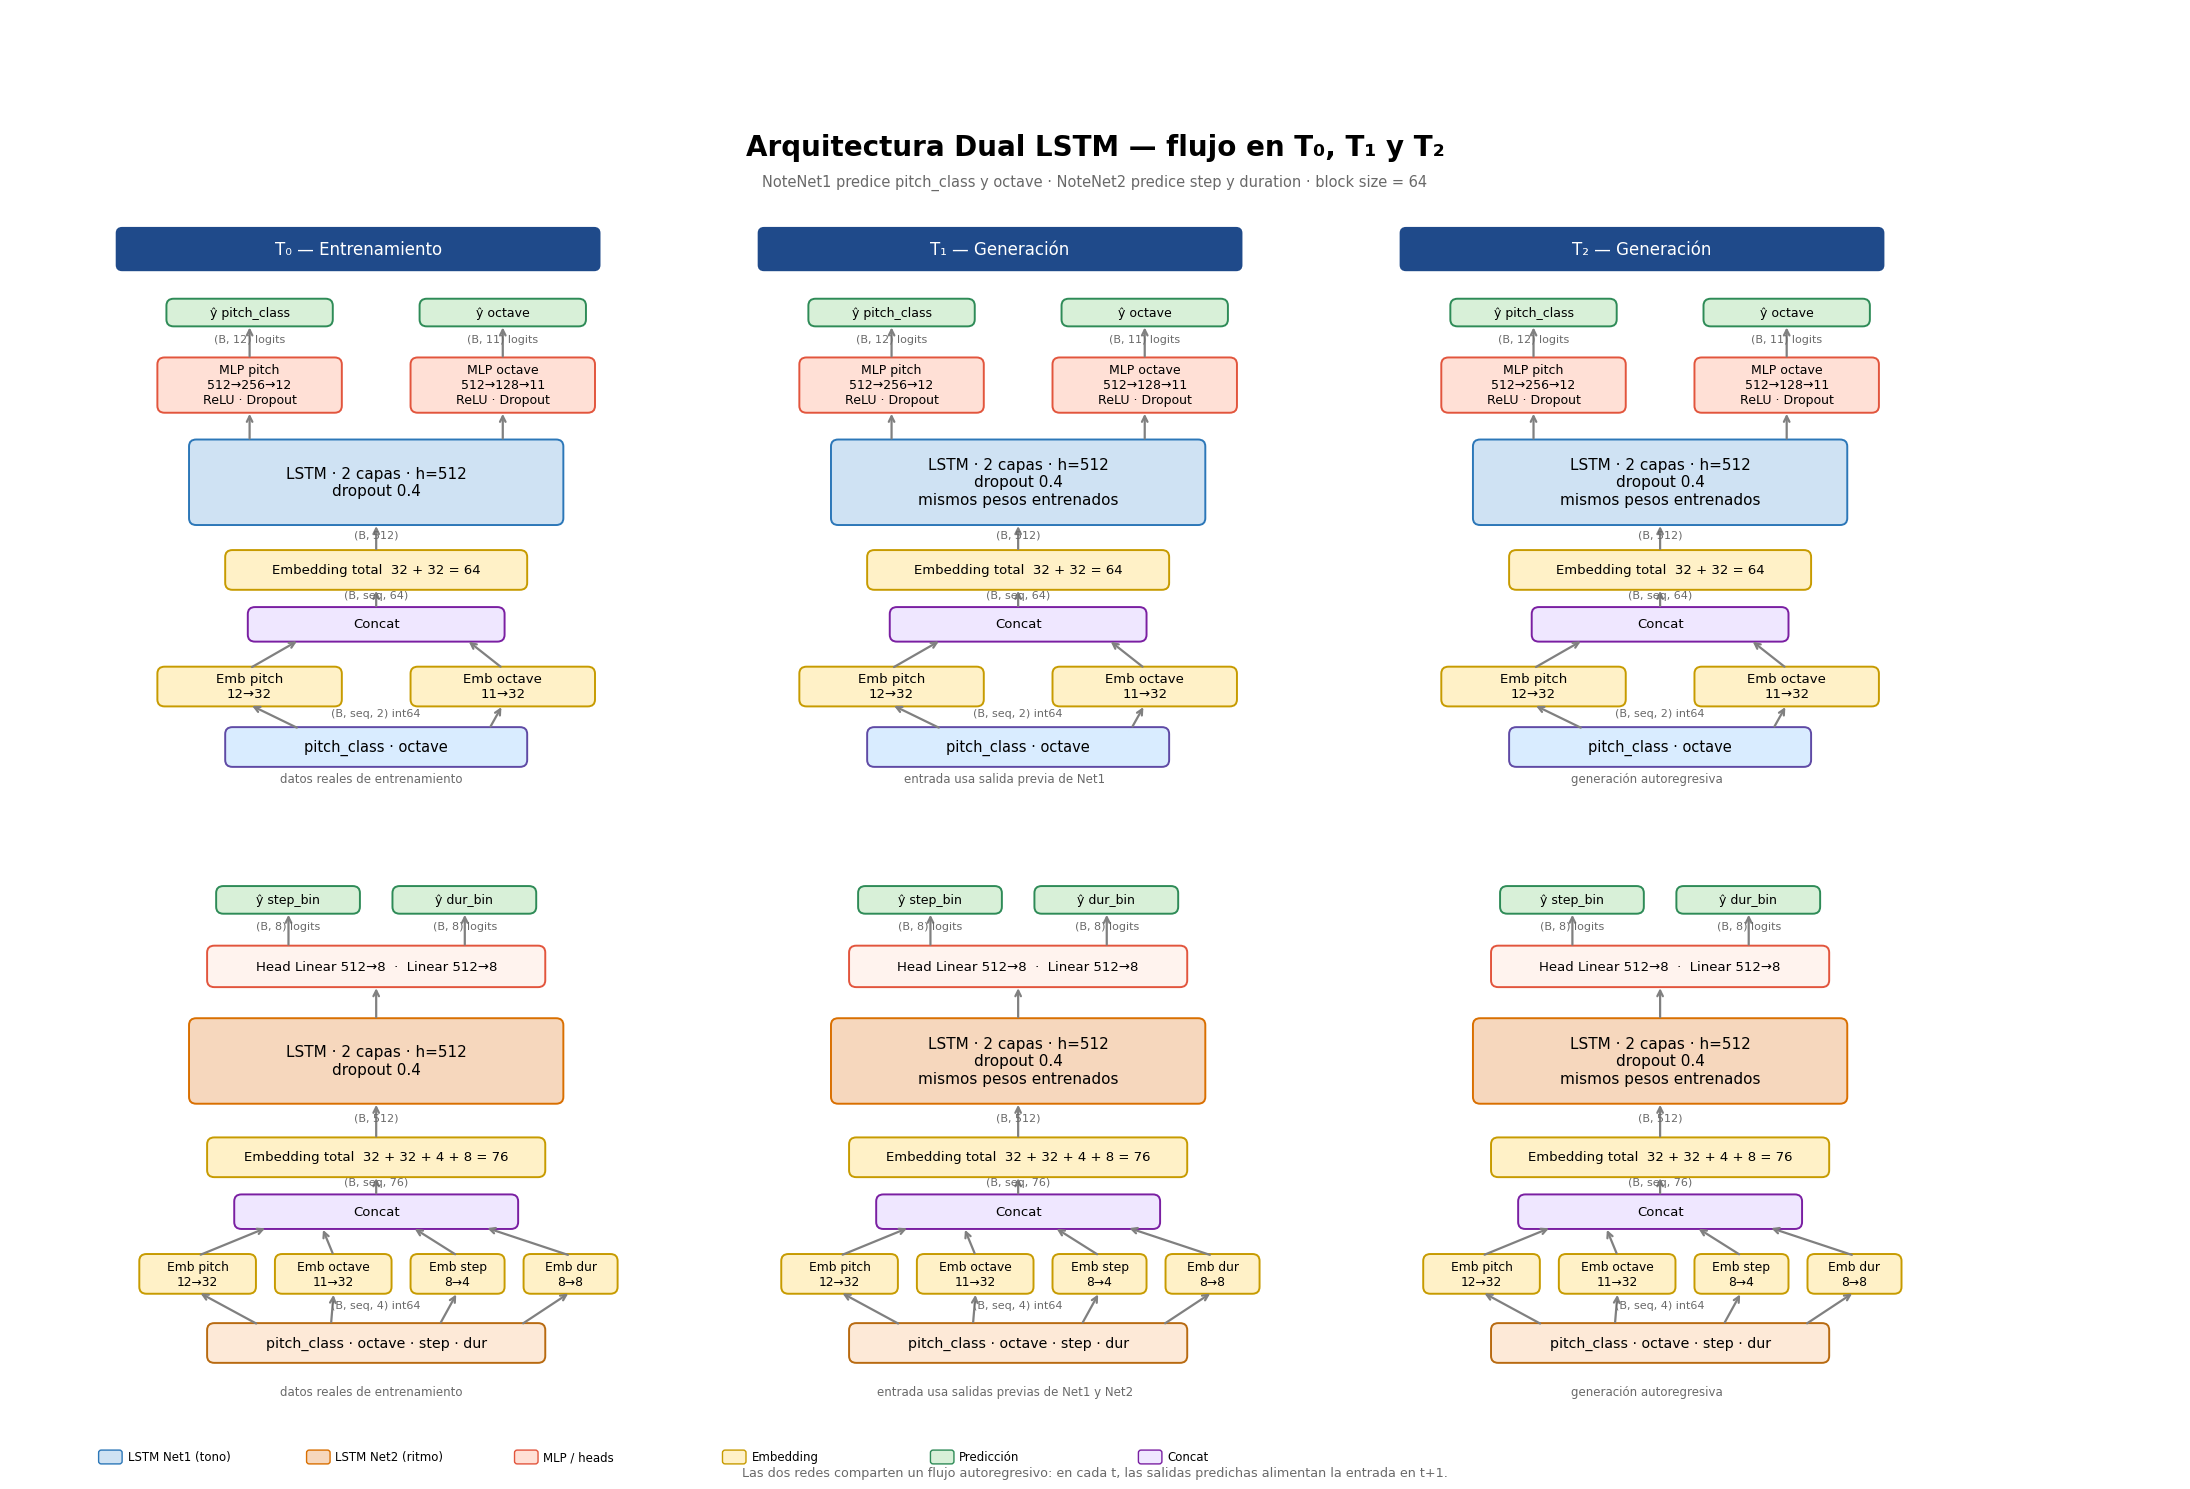

In [55]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# =========================
# Configuración
# =========================
LSTM_LAYERS = 2
HIDDEN_DIM  = 512
DROPOUT     = 0.4

EMB_PITCH   = 32
EMB_OCTAVE  = 32
EMB_STEP    = 4
EMB_DUR     = 8

PITCH_CLASS_VOCAB = 12
OCTAVE_VOCAB = 11
N_BINS = 8
BLOCK_SIZE = 64

INPUT_DIM_1 = EMB_PITCH + EMB_OCTAVE
INPUT_DIM_2 = EMB_PITCH + EMB_OCTAVE + EMB_STEP + EMB_DUR

# =========================
# Helpers
# =========================
def add_box(ax, x, y, w, h, text, fc, ec='black', lw=1.4, fontsize=10,
            color='black', alpha=1.0, radius=0.08, weight='normal'):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0.02,rounding_size={radius}",
        linewidth=lw, edgecolor=ec, facecolor=fc, alpha=alpha
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, color=color, wrap=True, fontweight=weight)
    return box

def add_arrow(ax, x1, y1, x2, y2, color='black', lw=1.6, ls='-', rad=0.0):
    ax.annotate(
        '', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='->', lw=lw, color=color, linestyle=ls,
            connectionstyle=f"arc3,rad={rad}"
        )
    )

def add_text(ax, x, y, s, size=8, color='dimgray', weight='normal', ha='center'):
    ax.text(x, y, s, fontsize=size, color=color, fontweight=weight, ha=ha)

def mid(a, b):
    return (a + b) / 2

# =========================
# Figura
# =========================
fig, ax = plt.subplots(figsize=(22, 15))
ax.set_xlim(0, 24)
ax.set_ylim(0, 17)
ax.axis('off')

# =========================
# Colores
# =========================
C_GROUP1 = '#dfeaf5'
C_GROUP2 = '#f7e8dc'

C_INPUT  = '#d9ecff'
C_CONCAT = '#efe7ff'
C_EMB    = '#fff1c7'
C_LSTM1  = '#cfe2f3'
C_LSTM2  = '#f6d7bd'
C_HEAD   = '#ffe0d6'
C_PRED   = '#d8f0d8'
C_TIMEL  = '#1f4a8a'

# =========================
# Título
# =========================
ax.text(12, 15.4, 'Arquitectura Dual LSTM — flujo en T₀, T₁ y T₂',
        ha='center', va='center', fontsize=20, fontweight='bold')

ax.text(12, 15.0,
        'NoteNet1 predice pitch_class y octave · NoteNet2 predice step y duration · block size = 64',
        ha='center', va='center', fontsize=10.5, color='dimgray')

# =========================
# Posiciones temporales
# =========================
time_x = [1.2, 8.3, 15.4]
time_titles = ['T₀ — Entrenamiento', 'T₁ — Generación', 'T₂ — Generación']

for tx, title in zip(time_x, time_titles):
    add_box(ax, tx, 14, 5.3, 0.45, title, fc=C_TIMEL, ec=C_TIMEL,
            fontsize=12, color='white', radius=0.06)

# =========================
# NoteNet1
# =========================
def draw_netenet1(ax, x0, stage='T0'):
    cx = x0 + 2.85

    # Input
    y_in_box = 8.25
    add_box(ax, x0+1.2, y_in_box, 3.3, 0.42, 'pitch_class · octave',
            fc=C_INPUT, ec='#5f4aa5', fontsize=10.5)

    # Embeddings
    y_emb = 8.95
    add_box(ax, x0+0.45, y_emb, 2.0, 0.42, 'Emb pitch\n12→32',
            fc=C_EMB, ec='#c79b00', fontsize=9.5)
    add_box(ax, x0+3.25, y_emb, 2.0, 0.42, 'Emb octave\n11→32',
            fc=C_EMB, ec='#c79b00', fontsize=9.5)

    add_arrow(ax, x0+2.0, 8.67, x0+1.45, y_emb, color='gray')
    add_arrow(ax, x0+4.1, 8.67, x0+4.25, y_emb, color='gray')
    add_text(ax, cx, mid(8.67, y_emb), '(B, seq, 2) int64')

    # Concat
    y_concat = 9.7
    add_box(ax, x0+1.45, y_concat, 2.8, 0.36, 'Concat',
            fc=C_CONCAT, ec='#7a1fa2', fontsize=9.5)
    add_arrow(ax, x0+1.45, 9.37, x0+2.0, y_concat, color='gray')
    add_arrow(ax, x0+4.25, 9.37, x0+3.85, y_concat, color='gray')

    # Emb total
    y_total = 10.3
    add_box(ax, x0+1.2, y_total, 3.3, 0.42,
            f'Embedding total  32 + 32 = {INPUT_DIM_1}',
            fc=C_EMB, ec='#c79b00', fontsize=9.5)
    add_arrow(ax, cx, 10.06, cx, y_total, color='gray')
    add_text(ax, cx, mid(10.06, y_total), f'(B, seq, {INPUT_DIM_1})')

    # LSTM
    y_lstm = 11.05
    lstm_text = f'LSTM · {LSTM_LAYERS} capas · h={HIDDEN_DIM}\ndropout {DROPOUT}'
    if stage != 'T0':
        lstm_text += '\nmismos pesos entrenados'
    add_box(ax, x0+0.8, y_lstm, 4.1, 0.95, lstm_text,
            fc=C_LSTM1, ec='#2c77b8', fontsize=11)
    add_arrow(ax, cx, 10.72, cx, y_lstm, color='gray')
    add_text(ax, cx, mid(10.72, y_lstm), f'(B, {HIDDEN_DIM})')

    # Heads
    y_head = 12.35
    add_box(ax, x0+0.45, y_head, 2.0, 0.6,
            f'MLP pitch\n{HIDDEN_DIM}→256→{PITCH_CLASS_VOCAB}\nReLU · Dropout',
            fc=C_HEAD, ec='#e2553d', fontsize=9)
    add_box(ax, x0+3.25, y_head, 2.0, 0.6,
            f'MLP octave\n{HIDDEN_DIM}→128→{OCTAVE_VOCAB}\nReLU · Dropout',
            fc=C_HEAD, ec='#e2553d', fontsize=9)

    add_arrow(ax, x0+1.45, 12.0, x0+1.45, y_head, color='gray')
    add_arrow(ax, x0+4.25, 12.0, x0+4.25, y_head, color='gray')

    # Predicciones
    y_pred = 13.35
    add_box(ax, x0+0.55, y_pred, 1.8, 0.28, 'ŷ pitch_class',
            fc=C_PRED, ec='seagreen', fontsize=9)
    add_box(ax, x0+3.35, y_pred, 1.8, 0.28, 'ŷ octave',
            fc=C_PRED, ec='seagreen', fontsize=9)

    add_arrow(ax, x0+1.45, 12.95, x0+1.45, y_pred, color='gray')
    add_arrow(ax, x0+4.25, 12.95, x0+4.25, y_pred, color='gray')
    add_text(ax, x0+1.45, mid(12.95, y_pred), f'(B, {PITCH_CLASS_VOCAB}) logits', size=8)
    add_text(ax, x0+4.25, mid(12.95, y_pred), f'(B, {OCTAVE_VOCAB}) logits', size=8)

# =========================
# NoteNet2
# =========================
def draw_netenet2(ax, x0, stage='T0'):
    cx = x0 + 2.85

    # Input
    y_in_box = 1.35
    add_box(ax, x0+1.0, y_in_box, 3.7, 0.42, 'pitch_class · octave · step · dur',
            fc='#fde9d7', ec='#b86a10', fontsize=10.2)

    # Embeddings
    y_emb = 2.15
    add_box(ax, x0+0.25, y_emb, 1.25, 0.42, 'Emb pitch\n12→32',
            fc=C_EMB, ec='#c79b00', fontsize=8.8)
    add_box(ax, x0+1.75, y_emb, 1.25, 0.42, 'Emb octave\n11→32',
            fc=C_EMB, ec='#c79b00', fontsize=8.8)
    add_box(ax, x0+3.25, y_emb, 1.0, 0.42, 'Emb step\n8→4',
            fc=C_EMB, ec='#c79b00', fontsize=8.8)
    add_box(ax, x0+4.5, y_emb, 1.0, 0.42, 'Emb dur\n8→8',
            fc=C_EMB, ec='#c79b00', fontsize=8.8)

    add_arrow(ax, x0+1.55, 1.77, x0+0.88, y_emb, color='gray')
    add_arrow(ax, x0+2.35, 1.77, x0+2.38, y_emb, color='gray')
    add_arrow(ax, x0+3.55, 1.77, x0+3.75, y_emb, color='gray')
    add_arrow(ax, x0+4.45, 1.77, x0+5.0, y_emb, color='gray')
    add_text(ax, cx, mid(1.77, y_emb), '(B, seq, 4) int64')

    # Concat
    y_concat = 2.9
    add_box(ax, x0+1.3, y_concat, 3.1, 0.36, 'Concat',
            fc=C_CONCAT, ec='#7a1fa2', fontsize=9.5)
    add_arrow(ax, x0+0.88, 2.57, x0+1.65, y_concat, color='gray')
    add_arrow(ax, x0+2.38, 2.57, x0+2.25, y_concat, color='gray')
    add_arrow(ax, x0+3.75, 2.57, x0+3.25, y_concat, color='gray')
    add_arrow(ax, x0+5.0, 2.57, x0+4.05, y_concat, color='gray')

    # Emb total
    y_total = 3.5
    add_box(ax, x0+1.0, y_total, 3.7, 0.42,
            f'Embedding total  32 + 32 + 4 + 8 = {INPUT_DIM_2}',
            fc=C_EMB, ec='#c79b00', fontsize=9.5)
    add_arrow(ax, cx, 3.26, cx, y_total, color='gray')
    add_text(ax, cx, mid(3.26, y_total), f'(B, seq, {INPUT_DIM_2})')

    # LSTM
    y_lstm = 4.35
    lstm_text = f'LSTM · {LSTM_LAYERS} capas · h={HIDDEN_DIM}\ndropout {DROPOUT}'
    if stage != 'T0':
        lstm_text += '\nmismos pesos entrenados'
    add_box(ax, x0+0.8, y_lstm, 4.1, 0.95, lstm_text,
            fc=C_LSTM2, ec='#d96f00', fontsize=11)
    add_arrow(ax, cx, 3.92, cx, y_lstm, color='gray')
    add_text(ax, cx, mid(3.92, y_lstm), f'(B, {HIDDEN_DIM})')

    # Head
    y_head = 5.7
    add_box(ax, x0+1.0, y_head, 3.7, 0.44,
            f'Head Linear {HIDDEN_DIM}→{N_BINS}  ·  Linear {HIDDEN_DIM}→{N_BINS}',
            fc='#fff3ee', ec='#e2553d', fontsize=9.5)
    add_arrow(ax, cx, 5.3, cx, y_head, color='gray')

    # Predicciones
    y_pred = 6.55
    add_box(ax, x0+1.1, y_pred, 1.55, 0.28, 'ŷ step_bin',
            fc=C_PRED, ec='seagreen', fontsize=9)
    add_box(ax, x0+3.05, y_pred, 1.55, 0.28, 'ŷ dur_bin',
            fc=C_PRED, ec='seagreen', fontsize=9)

    add_arrow(ax, x0+1.88, 6.14, x0+1.88, y_pred, color='gray')
    add_arrow(ax, x0+3.83, 6.14, x0+3.83, y_pred, color='gray')
    add_text(ax, x0+1.88, mid(6.14, y_pred), f'(B, {N_BINS}) logits', size=8)
    add_text(ax, x0+3.83, mid(6.14, y_pred), f'(B, {N_BINS}) logits', size=8)

# Dibujar
draw_netenet1(ax, time_x[0], 'T0')
draw_netenet1(ax, time_x[1], 'T1')
draw_netenet1(ax, time_x[2], 'T2')

draw_netenet2(ax, time_x[0], 'T0')
draw_netenet2(ax, time_x[1], 'T1')
draw_netenet2(ax, time_x[2], 'T2')

# =========================
# Notas inferiores
# =========================
add_text(ax, 4.0, 8.05, 'datos reales de entrenamiento', size=8.5)
add_text(ax, 4.0, 0.95, 'datos reales de entrenamiento', size=8.5)

add_text(ax, 11.0, 8.05, 'entrada usa salida previa de Net1', size=8.5)
add_text(ax, 11.0, 0.95, 'entrada usa salidas previas de Net1 y Net2', size=8.5)

add_text(ax, 18.1, 8.05, 'generación autoregresiva', size=8.5)
add_text(ax, 18.1, 0.95, 'generación autoregresiva', size=8.5)

# =========================
# Leyenda
# =========================
legend_y = 0.18
x = 1.0

legend_items = [
    ('LSTM Net1 (tono)', C_LSTM1, '#2c77b8'),
    ('LSTM Net2 (ritmo)', C_LSTM2, '#d96f00'),
    ('MLP / heads', C_HEAD, '#e2553d'),
    ('Embedding', C_EMB, '#c79b00'),
    ('Predicción', C_PRED, 'seagreen'),
    ('Concat', C_CONCAT, '#7a1fa2'),
]

for label, fc, ec in legend_items:
    add_box(ax, x, legend_y, 0.22, 0.12, '', fc=fc, ec=ec, lw=1.0, radius=0.03)
    ax.text(x+0.3, legend_y+0.06, label, va='center', fontsize=8.5)
    x += 2.3

ax.text(12, 0.02,
        'Las dos redes comparten un flujo autoregresivo: en cada t, las salidas predichas alimentan la entrada en t+1.',
        ha='center', fontsize=9.2, color='dimgray')

plt.tight_layout()
plt.show()